In [1]:
# Install the python-dotenv package
!pip install python-dotenv

In [5]:
# import necessary libraries
import re
import requests
from bs4 import BeautifulSoup
import json
from dotenv import load_dotenv
import pandas as pd
import os
import time

In [6]:
# Load environment variables from .env file
load_dotenv()

# Get the API key from environment variable
api_key = os.getenv("API_DATA")

# Define the URL for the CoinGecko API endpoint
url = "https://api.coingecko.com/api/v3/coins/markets"

# Set up headers with the API key
headers = {
    "x-cg-demo-api-key": api_key
}

# Initialize an empty list to store all the data
all_data = []

# Loop through the first 5 pages of results
for page in range(1, 6):

    # Set up the parameters for the API request
    params = {
        "vs_currency": "usd",
        "order": "market_cap_desc",
        "per_page": 100,
        "page": page
    }

    # Make the API request
    response = requests.get(
        url,
        params=params,
        headers=headers
    )

    # Print the page number and status code
    print("Page:", page, "Status:", response.status_code)

    # Check if request was successful
    if response.status_code == 200:

        # Parse the JSON response
        data = response.json()

        # Make sure data is a list
        if isinstance(data, list):
            all_data.extend(data)
        else:
            print("Unexpected response:", data)

    else:
        print("Error:", response.text)

    # Sleep for 1 second to avoid hitting the rate limit
    time.sleep(1)

# Convert the list of data to a pandas DataFrame
df = pd.DataFrame(all_data)

# Display the total number of rows and the first few rows of the DataFrame
print("Total rows:", len(df))
print(df.head())

Page: 1 Status: 200
Page: 2 Status: 200
Page: 3 Status: 200
Page: 4 Status: 200
Page: 5 Status: 200
Total rows: 500
            id symbol      name  \
0      bitcoin    btc   Bitcoin   
1     ethereum    eth  Ethereum   
2       tether   usdt    Tether   
3  binancecoin    bnb       BNB   
4       ripple    xrp       XRP   

                                               image  current_price  \
0  https://coin-images.coingecko.com/coins/images...    79022.00000   
1  https://coin-images.coingecko.com/coins/images...     2493.50000   
2  https://coin-images.coingecko.com/coins/images...        0.99983   
3  https://coin-images.coingecko.com/coins/images...      749.58000   
4  https://coin-images.coingecko.com/coins/images...        1.42000   

      market_cap  market_cap_rank  fully_diluted_valuation  total_volume  \
0  1586973116809              1.0             1.586976e+12  3.391819e+10   
1   304295458946              2.0             3.042955e+11  1.205647e+10   
2   183429215371  

In [7]:
# Display the DataFrame
df

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,79022.000000,1586973116809,1.0,1.586976e+12,3.391819e+10,79701.000000,...,2.008184e+07,2.100000e+07,126080.000000,-37.32359,2025-10-06T10:57:42.000Z,67.810000,1.164367e+05,2013-07-05T16:00:00.000Z,None,2026-09-09T11:40:20.000Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2493.500000,304295458946,2.0,3.042955e+11,1.205647e+10,2521.510000,...,1.220326e+08,NaN,4946.050000,-49.58597,2025-08-24T11:21:03.000Z,0.432979,5.757947e+05,2015-10-19T16:00:00.000Z,"{'times': 41.19381604030222, 'currency': 'btc'...",2026-09-09T11:40:20.000Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999830,183429215371,3.0,1.888952e+11,5.236219e+10,0.999995,...,1.889271e+11,NaN,1.320000,-24.43250,2018-07-23T16:00:00.000Z,0.572521,7.463640e+01,2015-03-01T16:00:00.000Z,None,2026-09-09T11:40:20.000Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,749.580000,99820715832,4.0,9.982072e+10,9.504559e+08,757.360000,...,1.331614e+08,2.000000e+08,1369.990000,-45.28584,2025-10-13T00:41:24.000Z,0.039818,1.882428e+06,2017-10-18T16:00:00.000Z,None,2026-09-09T11:40:20.000Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.420000,89285308718,5.0,1.422794e+11,2.631760e+09,1.450000,...,9.998563e+10,1.000000e+11,3.650000,-60.97770,2025-07-17T19:40:53.000Z,0.002686,5.287063e+04,2014-05-21T16:00:00.000Z,None,2026-09-09T11:40:20.000Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,mantis,m,Mantis,https://coin-images.coingecko.com/coins/images...,0.474470,47447004,429.0,4.744700e+07,4.702180e+03,0.000000,...,1.000000e+08,1.000000e+08,4.840000,-90.18883,2026-04-24T05:15:00.000Z,0.001337,3.539385e+04,2026-01-21T09:31:11.000Z,None,2026-08-15T22:22:10.000Z
496,dusk-network,dusk,DUSK,https://coin-images.coingecko.com/coins/images...,0.078308,47274984,483.0,4.727563e+07,2.594710e+06,0.079370,...,6.030604e+08,1.000000e+09,1.090000,-92.81519,2021-12-29T13:34:22.000Z,0.011133,6.034029e+02,2020-03-12T18:24:16.000Z,"{'times': 0.9398762590960935, 'currency': 'usd...",2026-09-09T11:41:10.000Z
497,jupusd,jupusd,JupUSD,https://coin-images.coingecko.com/coins/images...,0.999705,47215602,484.0,4.721560e+07,1.686224e+07,0.999802,...,4.723070e+07,NaN,1.023000,-2.31915,2026-04-26T05:01:00.000Z,0.124871,7.005882e+02,2026-07-09T09:10:50.000Z,None,2026-09-09T11:41:10.000Z
498,altlayer,alt,AltLayer,https://coin-images.coingecko.com/coins/images...,0.006605,47068562,485.0,6.604826e+07,4.013706e+06,0.006697,...,1.000000e+10,1.000000e+10,0.676743,-99.02394,2024-03-28T15:20:10.000Z,0.005366,2.310559e+01,2026-06-06T05:03:15.000Z,None,2026-09-09T11:41:10.000Z


In [8]:
# Save the DataFrame to a CSV file
df.to_csv("cryptocurrency_data.csv", index=False)

In [9]:
# Display the shape of the DataFrame
df.shape

(500, 26)

In [10]:
# Display the data types of each column in the DataFrame
df.dtypes

id                                      str
symbol                                  str
name                                    str
image                                   str
current_price                       float64
market_cap                            int64
market_cap_rank                     float64
fully_diluted_valuation             float64
total_volume                        float64
high_24h                            float64
low_24h                             float64
price_change_24h                    float64
price_change_percentage_24h         float64
market_cap_change_24h               float64
market_cap_change_percentage_24h    float64
circulating_supply                  float64
total_supply                        float64
max_supply                          float64
ath                                 float64
ath_change_percentage               float64
ath_date                                str
atl                                 float64
atl_change_percentage           

In [11]:
# Display the column names of the DataFrame
df.columns

Index(['id', 'symbol', 'name', 'image', 'current_price', 'market_cap',
       'market_cap_rank', 'fully_diluted_valuation', 'total_volume',
       'high_24h', 'low_24h', 'price_change_24h',
       'price_change_percentage_24h', 'market_cap_change_24h',
       'market_cap_change_percentage_24h', 'circulating_supply',
       'total_supply', 'max_supply', 'ath', 'ath_change_percentage',
       'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi',
       'last_updated'],
      dtype='str')

In [12]:
# Display the summary information of the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                500 non-null    str    
 1   symbol                            500 non-null    str    
 2   name                              500 non-null    str    
 3   image                             500 non-null    str    
 4   current_price                     500 non-null    float64
 5   market_cap                        500 non-null    int64  
 6   market_cap_rank                   498 non-null    float64
 7   fully_diluted_valuation           500 non-null    float64
 8   total_volume                      500 non-null    float64
 9   high_24h                          500 non-null    float64
 10  low_24h                           500 non-null    float64
 11  price_change_24h                  484 non-null    float64
 12  price_change_percen

In [13]:
# Check for missing values in the DataFrame
df.isnull().sum()

id                                    0
symbol                                0
name                                  0
image                                 0
current_price                         0
market_cap                            0
market_cap_rank                       2
fully_diluted_valuation               0
total_volume                          0
high_24h                              0
low_24h                               0
price_change_24h                     16
price_change_percentage_24h          16
market_cap_change_24h                18
market_cap_change_percentage_24h     18
circulating_supply                    0
total_supply                          0
max_supply                          208
ath                                   0
ath_change_percentage                 0
ath_date                              0
atl                                   0
atl_change_percentage                 0
atl_date                              0
roi                                 460


In [14]:
# Check for the total number of missing values in the DataFrame
df.isnull().sum().sum()

np.int64(738)

In [15]:
# Check for duplicate rows in the DataFrame
duplicate_count = df.astype(str).duplicated().sum()

# Display the number of duplicate rows
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:
# Check for missing values, duplicates, and data type of the "id" column
print("Missing values in 'id' column:", df["id"].isnull().sum())
print("Duplicate rows in 'id' column:", df["id"].duplicated().sum())
print("Data type of 'id' column:", df["id"].dtype)

Missing values in 'id' column: 0
Duplicate rows in 'id' column: 0
Data type of 'id' column: str


In [17]:
# Check for missing values, duplicates, and data type of the "symbol" column
print("Missing Values in symbol column:", df["symbol"].isnull().sum())
print("Duplicates in symbol column:", df["symbol"].duplicated().sum())
print("Data type of symbol column:", df["symbol"].dtype)

Missing Values in symbol column: 0
Duplicates in symbol column: 6
Data type of symbol column: str


In [18]:
# Check for missing values, duplicates, and data type of the "name" column
print("Missing Values in name column:", df["name"].isnull().sum())
print("Duplicates in name column:", df["name"].duplicated().sum())
print("Data type of name column:", df["name"].dtype)

Missing Values in name column: 0
Duplicates in name column: 1
Data type of name column: str


In [19]:
# Check for missing values, duplicates, and data type of the "image" column
print("Missing Values in image column:", df["image"].isnull().sum())
print("Duplicates in image column:", df["image"].duplicated().sum())
print("Data type of image column:", df["image"].dtype)

Missing Values in image column: 0
Duplicates in image column: 0
Data type of image column: str


In [20]:
# Check for missing values, duplicates, and data type of the "current_price" column
print("Missing Values in current_price column:", df["current_price"].isnull().sum())
print("Duplicates in current_price column:", df["current_price"].duplicated().sum())
print("Data type of current_price column:", df["current_price"].dtype)

Missing Values in current_price column: 0
Duplicates in current_price column: 30
Data type of current_price column: float64


In [21]:
# Check for missing values, duplicates, and data type of the "market_cap" column
print("Missing Values in market_cap column:", df["market_cap"].isnull().sum())
print("Duplicates in market_cap column:", df["market_cap"].duplicated().sum())
print("Data type of market_cap column:", df["market_cap"].dtype)

Missing Values in market_cap column: 0
Duplicates in market_cap column: 0
Data type of market_cap column: int64


In [22]:
# Check for missing values, duplicates, and data type of the "market_cap_rank" column
print("Missing Values in market_cap_rank column:", df["market_cap_rank"].isnull().sum())
print("Duplicates in market_cap_rank column:", df["market_cap_rank"].duplicated().sum())
print("Data type of market_cap_rank column:", df["market_cap_rank"].dtype)

Missing Values in market_cap_rank column: 2
Duplicates in market_cap_rank column: 13
Data type of market_cap_rank column: float64


In [23]:
# Fill missing values in the "market_cap_rank" column with 0
df["market_cap_rank"]=df["market_cap_rank"].fillna(0)
print("Missing Values in market_cap_rank column after filling:", df["market_cap_rank"].isnull().sum())

Missing Values in market_cap_rank column after filling: 0


In [24]:
# Check for missing values, duplicates, and data type of the "fully_diluted_valuation" column
print("Missing Values in fully_diluted_valuation column:", df["fully_diluted_valuation"].isnull().sum())
print("Duplicates in fully_diluted_valuation column:", df["fully_diluted_valuation"].duplicated().sum())
print("Data type of fully_diluted_valuation column:", df["fully_diluted_valuation"].dtype)

Missing Values in fully_diluted_valuation column: 0
Duplicates in fully_diluted_valuation column: 1
Data type of fully_diluted_valuation column: float64


In [25]:
# Check for missing values, duplicates, and data type of the "total_volume" column
print("Missing Values in total_volume column:", df["total_volume"].isnull().sum())
print("Duplicates in total_volume column:", df["total_volume"].duplicated().sum())
print("Data type of total_volume column:", df["total_volume"].dtype)

Missing Values in total_volume column: 0
Duplicates in total_volume column: 40
Data type of total_volume column: float64


In [26]:
# Check for missing values, duplicates, and data type of the "high_24h" column
print("Missing Values in high_24h column:", df["high_24h"].isnull().sum())
print("Duplicates in high_24h column:", df["high_24h"].duplicated().sum())
print("Data type of high_24h column:", df["high_24h"].dtype)

Missing Values in high_24h column: 0
Duplicates in high_24h column: 47
Data type of high_24h column: float64


In [27]:
# Check for missing values, duplicates, and data type of the "low_24h" column
print("Missing Values in low_24h column:", df["low_24h"].isnull().sum())
print("Duplicates in low_24h column:", df["low_24h"].duplicated().sum())
print("Data type of low_24h column:", df["low_24h"].dtype)

Missing Values in low_24h column: 0
Duplicates in low_24h column: 35
Data type of low_24h column: float64


In [28]:
# Check for missing values, duplicates, and data type of the "price_change_24h" column
print("Missing Values in price_change_24h column:", df["price_change_24h"].isnull().sum())
print("Duplicates in price_change_24h column:", df["price_change_24h"].duplicated().sum())
print("Data type of price_change_24h column:", df["price_change_24h"].dtype)

Missing Values in price_change_24h column: 16
Duplicates in price_change_24h column: 33
Data type of price_change_24h column: float64


In [29]:
# Fill missing values in the "price_change_24h" column with the median value
df["price_change_24h"] = df["price_change_24h"].fillna(
    df["price_change_24h"].median()
)
print("Missing Values in price_change_24h column after filling:", df["price_change_24h"].isnull().sum())

Missing Values in price_change_24h column after filling: 0


In [30]:
# Check for missing values, duplicates, and data type of the "price_change_percentage_24h" column
print("Missing Values in price_change_percentage_24h column:", df["price_change_percentage_24h"].isnull().sum())
print("Duplicates in price_change_percentage_24h column:", df["price_change_percentage_24h"].duplicated().sum())
print("Data type of price_change_percentage_24h column:", df["price_change_percentage_24h"].dtype)


Missing Values in price_change_percentage_24h column: 16
Duplicates in price_change_percentage_24h column: 34
Data type of price_change_percentage_24h column: float64


In [31]:
# Fill missing values in the "price_change_percentage_24h" column with the median value
df["price_change_percentage_24h"] = df["price_change_percentage_24h"].fillna(
    df["price_change_percentage_24h"].median()
)
print(df["price_change_percentage_24h"].isnull().sum())

0


In [32]:
# Check for missing values, duplicates, and data type of the "market_cap_change_24h" column
print("Missing Values in market_cap_change_24h column:", df["market_cap_change_24h"].isnull().sum())
print("Duplicates in market_cap_change_24h column:", df["market_cap_change_24h"].duplicated().sum())
print("Data type of market_cap_change_24h column:", df["market_cap_change_24h"].dtype)

Missing Values in market_cap_change_24h column: 18
Duplicates in market_cap_change_24h column: 30
Data type of market_cap_change_24h column: float64


In [33]:
# Fill missing values in the "market_cap_change_24h" column with the median value
df["market_cap_change_24h"] = df["market_cap_change_24h"].fillna(
    df["market_cap_change_24h"].median()
)
print("Missing Values in market_cap_change_24h column after filling:", df["market_cap_change_24h"].isnull().sum())

Missing Values in market_cap_change_24h column after filling: 0


In [34]:
# Check for missing values, duplicates, and data type of the "market_cap_change_percentage_24h" column
print("Missing Values in market_cap_change_percentage_24h column:", df["market_cap_change_percentage_24h"].isnull().sum())
print("Duplicates in market_cap_change_percentage_24h column:", df["market_cap_change_percentage_24h"].duplicated().sum())
print("Data type of market_cap_change_percentage_24h column:", df["market_cap_change_percentage_24h"].dtype)

Missing Values in market_cap_change_percentage_24h column: 18
Duplicates in market_cap_change_percentage_24h column: 33
Data type of market_cap_change_percentage_24h column: float64


In [35]:
# Fill missing values in the "market_cap_change_percentage_24h" column with the median value
df["market_cap_change_percentage_24h"] = df["market_cap_change_percentage_24h"].fillna(
    df["market_cap_change_percentage_24h"].median()
)
print("Missing Values in market_cap_change_percentage_24h column after filling:", df["market_cap_change_percentage_24h"].isnull().sum())

Missing Values in market_cap_change_percentage_24h column after filling: 0


In [36]:
# Check for missing values, duplicates, and data type of the "circulating_supply" column
print("Missing Values in circulating_supply column:", df["circulating_supply"].isnull().sum())
print("Duplicates in circulating_supply column:", df["circulating_supply"].duplicated().sum())
print("Data type of circulating_supply column:", df["circulating_supply"].dtype)

Missing Values in circulating_supply column: 0
Duplicates in circulating_supply column: 26
Data type of circulating_supply column: float64


In [37]:
# Check for missing values, duplicates, and data type of the "total_supply" column
print("Missing Values in total_supply column:", df["total_supply"].isnull().sum())
print("Duplicates in total_supply column:", df["total_supply"].duplicated().sum())
print("Data type of total_supply column:", df["total_supply"].dtype)

Missing Values in total_supply column: 0
Duplicates in total_supply column: 108
Data type of total_supply column: float64


In [38]:
# Check for missing values, duplicates, and data type of the "max_supply" column
print("Missing Values in max_supply column:", df["max_supply"].isnull().sum())
print("Duplicates in max_supply column:", df["max_supply"].duplicated().sum())
print("Data type of max_supply column:", df["max_supply"].dtype)

Missing Values in max_supply column: 208
Duplicates in max_supply column: 394
Data type of max_supply column: float64


In [39]:
# Fill missing values in the "max_supply" column with the median value
df["max_supply"] = df["max_supply"].fillna(
    df["max_supply"].median()
)
print("Missing Values in max_supply column after filling:", df["max_supply"].isnull().sum())

Missing Values in max_supply column after filling: 0


In [40]:
# Check for missing values, duplicates, and data type of the "ath" column
print("Missing Values in ath column:", df["ath"].isnull().sum())
print("Duplicates in ath column:", df["ath"].duplicated().sum())
print("Data type of ath column:", df["ath"].dtype)

Missing Values in ath column: 0
Duplicates in ath column: 48
Data type of ath column: float64


In [41]:
# Check for missing values, duplicates, and data type of the "ath_change_percentage" column
print("Missing Values in ath_change_percentage column:", df["ath_change_percentage"].isnull().sum())
print("Duplicates in ath_change_percentage column:", df["ath_change_percentage"].duplicated().sum())
print("Data type of ath_change_percentage column:", df["ath_change_percentage"].dtype)

Missing Values in ath_change_percentage column: 0
Duplicates in ath_change_percentage column: 26
Data type of ath_change_percentage column: float64


In [42]:
# Check for missing values, duplicates, and data type of the "ath_date" column
print("Missing Values in ath_date column:", df["ath_date"].isnull().sum())
print("Duplicates in ath_date column:", df["ath_date"].duplicated().sum())
print("Data type of ath_date column:", df["ath_date"].dtype)
df["ath_time"] = pd.to_datetime(df["ath_date"], errors='coerce')
print(df["ath_time"].dtype)

Missing Values in ath_date column: 0
Duplicates in ath_date column: 9
Data type of ath_date column: str
datetime64[us, UTC]


In [43]:
# Check for missing values, duplicates, and data type of the "atl" column
print("Missing Values in atl column:", df["atl"].isnull().sum())
print("Duplicates in atl column:", df["atl"].duplicated().sum())
print("Data type of atl column:", df["atl"].dtype)

Missing Values in atl column: 0
Duplicates in atl column: 17
Data type of atl column: float64


In [44]:
# Check for missing values, duplicates, and data type of the "atl_change_percentage" column
print("Missing Values in atl_change_percentage column:", df["atl_change_percentage"].isnull().sum())
print("Duplicates in atl_change_percentage column:", df["atl_change_percentage"].duplicated().sum())
print("Data type of atl_change_percentage column:", df["atl_change_percentage"].dtype)

Missing Values in atl_change_percentage column: 0
Duplicates in atl_change_percentage column: 16
Data type of atl_change_percentage column: float64


In [45]:
# Check for missing values, duplicates, and data type of the "atl_date" column
print("Missing Values in atl_date column:", df["atl_date"].isnull().sum())
print("Duplicates in atl_date column:", df["atl_date"].duplicated().sum())
print("Data type of atl_date column:", df["atl_date"].dtype)
df["atl_time"] = pd.to_datetime(df["atl_date"], errors='coerce')
print("Data type of atl_time column:", df["atl_time"].dtype)

Missing Values in atl_date column: 0
Duplicates in atl_date column: 31
Data type of atl_date column: str
Data type of atl_time column: datetime64[us, UTC]


In [46]:
# Check for missing values, duplicates, and data type of the "roi" column
print("Missing Values in roi column:", df["roi"].isnull().sum())
print("Duplicates in roi column:", df["roi"].duplicated().sum())
print("Data type of roi column:", df["roi"].dtype)

Missing Values in roi column: 460
Duplicates in roi column: 459
Data type of roi column: object


In [47]:
# Fill missing values in the "roi" column with 0
df["roi"] = df["roi"].fillna(0)
print("Missing Values in roi column:", df["roi"].isnull().sum())

Missing Values in roi column: 0


In [48]:
# Rename columns for better readability
df = df.rename(columns={
    "id": "crypto_id",
    "symbol": "crypto_symbol",
    "name": "crypto_name",
    "image": "image_url",
    "current_price": "current_price",
    "market_cap": "market_cap",
    "market_cap_rank": "market_cap_rank",
    "fully_diluted_valuation": "fully_diluted_valuation",
    "total_volume": "24h_trading_volume",
    "high_24h": "24h_high_price",
    "low_24h": "24h_low_price",
    "price_change_24h": "24h_price_change",
    "price_change_percentage_24h": "24h_price_change_percentage",
    "market_cap_change_24h": "24h_market_cap_change",
    "market_cap_change_percentage_24h": "24h_market_cap_change_percentage",
    "circulating_supply": "circulating_supply",
    "total_supply": "total_supply",
    "max_supply": "max_supply",
    "ath": "all_time_high",
    "ath_change_percentage": "ath_change_percentage",
    "ath_date": "all_time_high_date",
    "atl": "all_time_low",
    "atl_change_percentage": "atl_change_percentage",
    "atl_date": "all_time_low_date",
    "roi": "return_on_investment",
    "last_updated": "last_updated"
})

In [49]:
df.columns = df.columns.str.title()

In [50]:
# Display the column names of the DataFrame
df.columns

Index(['Crypto_Id', 'Crypto_Symbol', 'Crypto_Name', 'Image_Url',
       'Current_Price', 'Market_Cap', 'Market_Cap_Rank',
       'Fully_Diluted_Valuation', '24H_Trading_Volume', '24H_High_Price',
       '24H_Low_Price', '24H_Price_Change', '24H_Price_Change_Percentage',
       '24H_Market_Cap_Change', '24H_Market_Cap_Change_Percentage',
       'Circulating_Supply', 'Total_Supply', 'Max_Supply', 'All_Time_High',
       'Ath_Change_Percentage', 'All_Time_High_Date', 'All_Time_Low',
       'Atl_Change_Percentage', 'All_Time_Low_Date', 'Return_On_Investment',
       'Last_Updated', 'Ath_Time', 'Atl_Time'],
      dtype='str')

In [51]:
# Fill missing values in the "24H_Market_Cap_Change" column with the median value
df["24H_Market_Cap_Change"] = df["24H_Market_Cap_Change"].fillna(
    df["24H_Market_Cap_Change"].median()
)

In [52]:
# Check for total missing values in the DataFrame
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [53]:
# Check for duplicate rows in the DataFrame
print("Duplicate rows:", df.astype(str).duplicated().sum())

Duplicate rows: 0


In [54]:
# Save the cleaned DataFrame to a new CSV file
df.to_csv("cryptocurrency_market_clean_data.csv", index=False)

### Cryptocurrency Market Overview

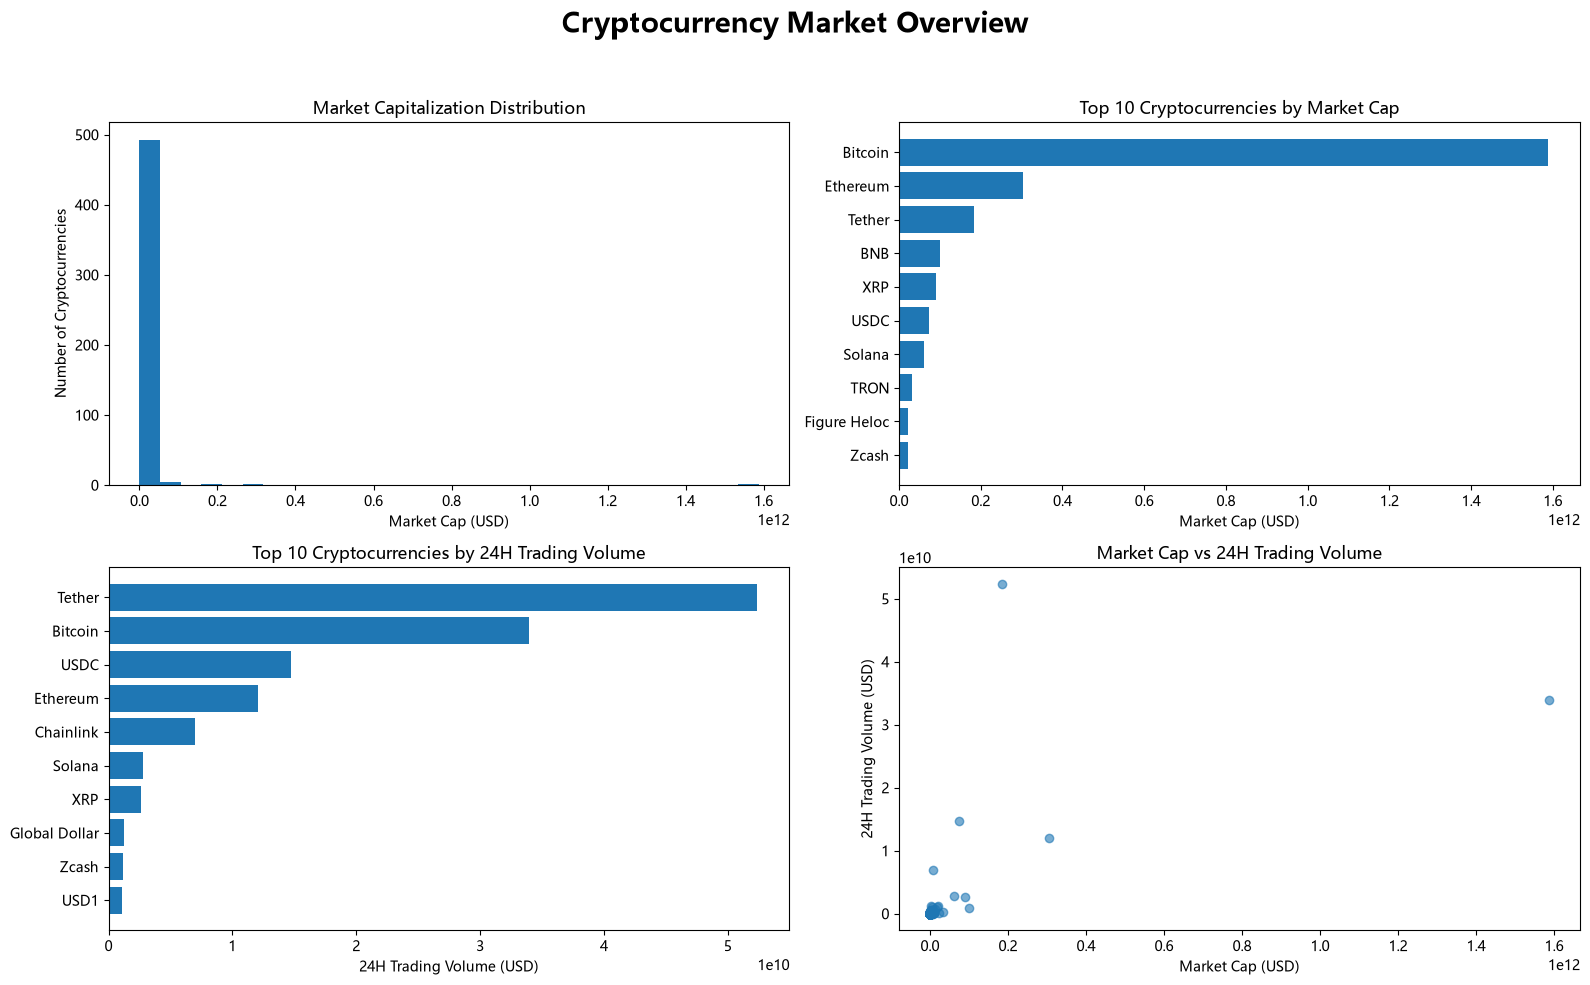

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("cryptocurrency_market_clean_data.csv")

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -----------------------------------------
# 1. Market Cap Distribution
# -----------------------------------------
axes[0, 0].hist(df["Market_Cap"], bins=30)

axes[0, 0].set_title("Market Capitalization Distribution")
axes[0, 0].set_xlabel("Market Cap (USD)")
axes[0, 0].set_ylabel("Number of Cryptocurrencies")


# -----------------------------------------
# 2. Top 10 Market Cap
# -----------------------------------------
top_market = (
    df.nlargest(10, "Market_Cap")
      .sort_values("Market_Cap")
)

axes[0, 1].barh(
    top_market["Crypto_Name"],
    top_market["Market_Cap"]
)

axes[0, 1].set_title("Top 10 Cryptocurrencies by Market Cap")
axes[0, 1].set_xlabel("Market Cap (USD)")


# -----------------------------------------
# 3. Top 10 Trading Volume
# -----------------------------------------
top_volume = (
    df.nlargest(10, "24H_Trading_Volume")
      .sort_values("24H_Trading_Volume")
)

axes[1, 0].barh(
    top_volume["Crypto_Name"],
    top_volume["24H_Trading_Volume"]
)

axes[1, 0].set_title("Top 10 Cryptocurrencies by 24H Trading Volume")
axes[1, 0].set_xlabel("24H Trading Volume (USD)")


# -----------------------------------------
# 4. Market Cap vs Trading Volume
# -----------------------------------------
axes[1, 1].scatter(
    df["Market_Cap"],
    df["24H_Trading_Volume"],
    alpha=0.6
)

axes[1, 1].set_title("Market Cap vs 24H Trading Volume")
axes[1, 1].set_xlabel("Market Cap (USD)")
axes[1, 1].set_ylabel("24H Trading Volume (USD)")


# -----------------------------------------
# Main Title
# -----------------------------------------
fig.suptitle(
    "Cryptocurrency Market Overview",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Price Performance

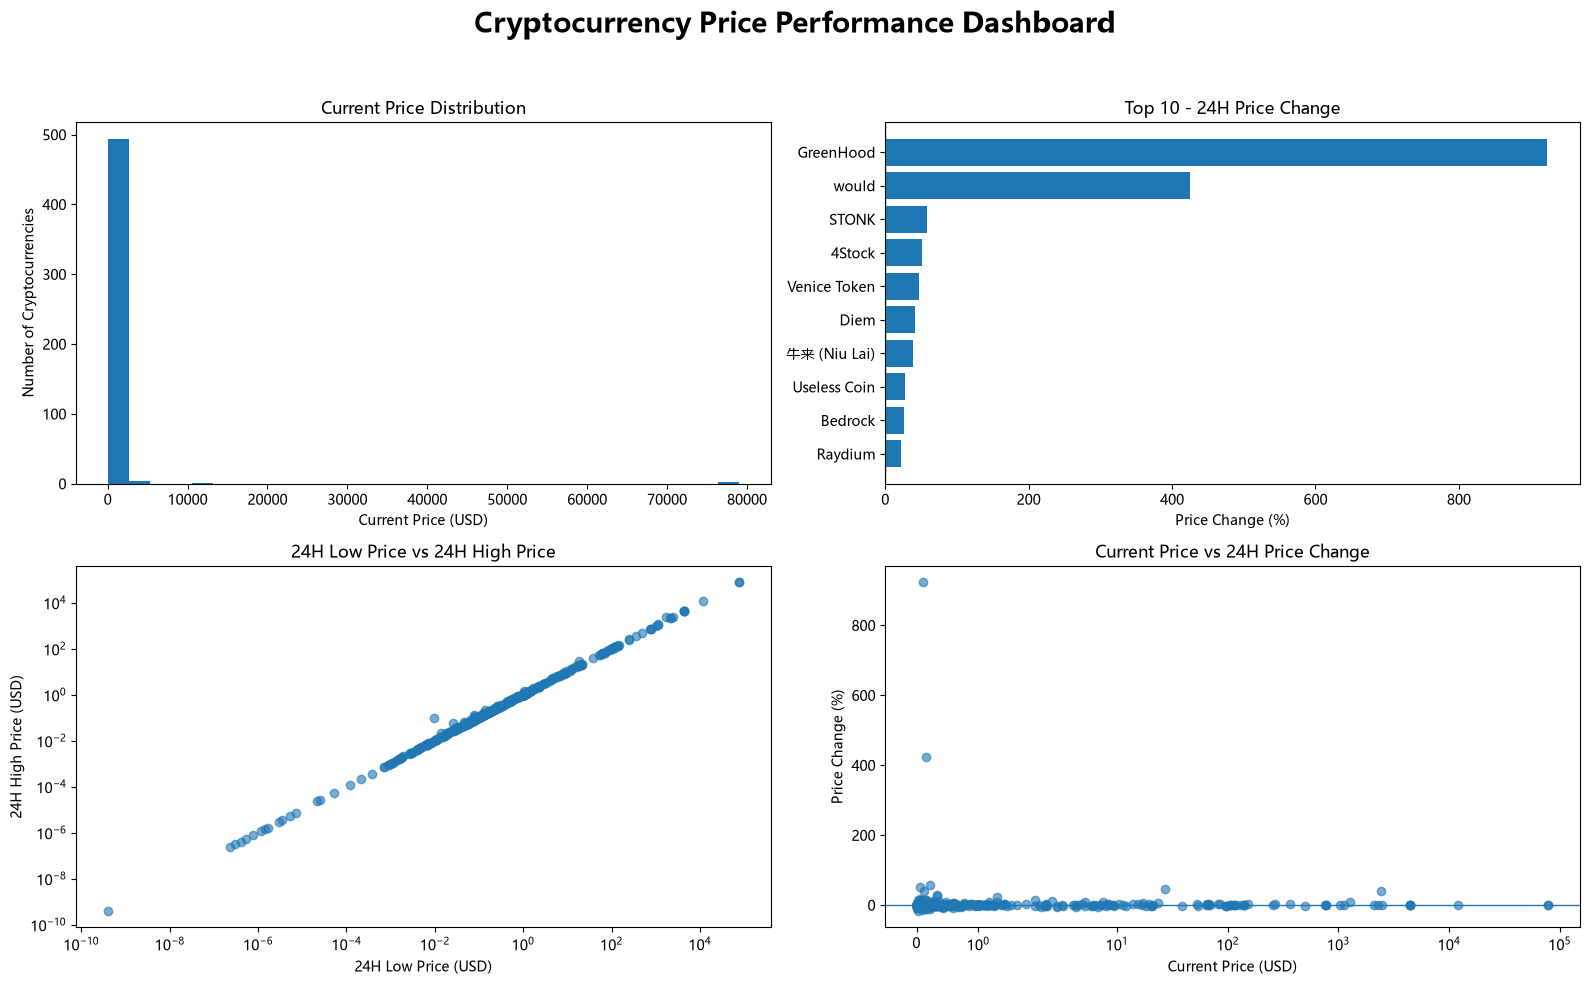

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("cryptocurrency_market_clean_data.csv")

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -----------------------------------------
# 1. Current Price Distribution
# -----------------------------------------
axes[0, 0].hist(df["Current_Price"], bins=30)

axes[0, 0].set_title("Current Price Distribution")
axes[0, 0].set_xlabel("Current Price (USD)")
axes[0, 0].set_ylabel("Number of Cryptocurrencies")


# -----------------------------------------
# 2. Top 10 - 24H Price Change %
# -----------------------------------------
top_change = (
    df.assign(
        Absolute_Change=df["24H_Price_Change_Percentage"].abs()
    )
    .nlargest(10, "Absolute_Change")
    .sort_values("24H_Price_Change_Percentage")
)

axes[0, 1].barh(
    top_change["Crypto_Name"],
    top_change["24H_Price_Change_Percentage"]
)

axes[0, 1].set_title("Top 10 - 24H Price Change")
axes[0, 1].set_xlabel("Price Change (%)")
axes[0, 1].axvline(0, linewidth=1)


# -----------------------------------------
# 3. 24H Low vs 24H High
# -----------------------------------------
axes[1, 0].scatter(
    df["24H_Low_Price"],
    df["24H_High_Price"],
    alpha=0.6
)

axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")

axes[1, 0].set_title("24H Low Price vs 24H High Price")
axes[1, 0].set_xlabel("24H Low Price (USD)")
axes[1, 0].set_ylabel("24H High Price (USD)")


# -----------------------------------------
# 4. Current Price vs 24H Price Change
# -----------------------------------------
axes[1, 1].scatter(
    df["Current_Price"],
    df["24H_Price_Change_Percentage"],
    alpha=0.6
)

axes[1, 1].set_xscale("symlog")

axes[1, 1].set_title("Current Price vs 24H Price Change")
axes[1, 1].set_xlabel("Current Price (USD)")
axes[1, 1].set_ylabel("Price Change (%)")

axes[1, 1].axhline(0, linewidth=1)


# -----------------------------------------
# Main Title
# -----------------------------------------
fig.suptitle(
    "Cryptocurrency Price Performance Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Supply & Historical Performance

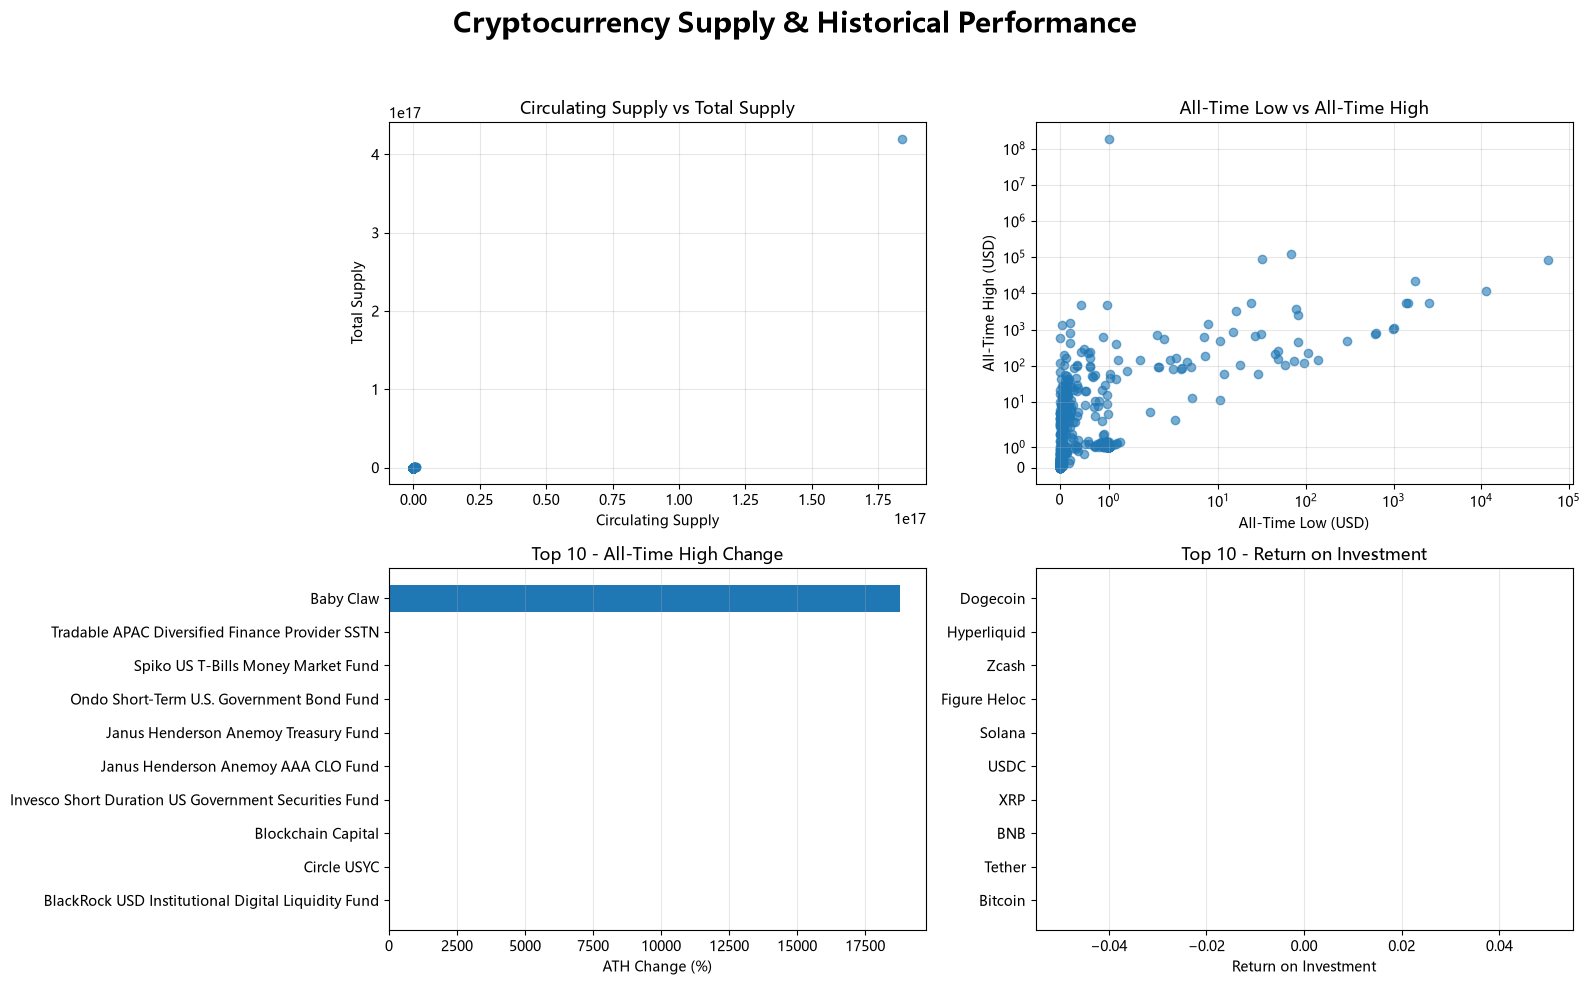

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("cryptocurrency_market_clean_data.csv")

# Convert required columns to numeric
numeric_columns = [
    "Circulating_Supply",
    "Total_Supply",
    "All_Time_Low",
    "All_Time_High",
    "Ath_Change_Percentage",
    "Return_On_Investment"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# -----------------------------------------
# 1. Circulating Supply vs Total Supply
# -----------------------------------------
axes[0, 0].scatter(
    df["Circulating_Supply"],
    df["Total_Supply"],
    alpha=0.6
)

axes[0, 0].set_title("Circulating Supply vs Total Supply")
axes[0, 0].set_xlabel("Circulating Supply")
axes[0, 0].set_ylabel("Total Supply")
axes[0, 0].grid(alpha=0.3)


# -----------------------------------------
# 2. All-Time Low vs All-Time High
# -----------------------------------------
axes[0, 1].scatter(
    df["All_Time_Low"],
    df["All_Time_High"],
    alpha=0.6
)

axes[0, 1].set_xscale("symlog")
axes[0, 1].set_yscale("symlog")

axes[0, 1].set_title("All-Time Low vs All-Time High")
axes[0, 1].set_xlabel("All-Time Low (USD)")
axes[0, 1].set_ylabel("All-Time High (USD)")
axes[0, 1].grid(alpha=0.3)


# -----------------------------------------
# 3. Top 10 ATH Change
# -----------------------------------------
top_ath = (
    df.dropna(subset=["Ath_Change_Percentage"])
      .nlargest(10, "Ath_Change_Percentage")
      .sort_values("Ath_Change_Percentage")
)

axes[1, 0].barh(
    top_ath["Crypto_Name"],
    top_ath["Ath_Change_Percentage"]
)

axes[1, 0].set_title("Top 10 - All-Time High Change")
axes[1, 0].set_xlabel("ATH Change (%)")
axes[1, 0].grid(axis="x", alpha=0.3)


# -----------------------------------------
# 4. Top 10 ROI
# -----------------------------------------
top_roi = (
    df.dropna(subset=["Return_On_Investment"])
      .nlargest(10, "Return_On_Investment")
      .sort_values("Return_On_Investment")
)

axes[1, 1].barh(
    top_roi["Crypto_Name"],
    top_roi["Return_On_Investment"]
)

axes[1, 1].set_title("Top 10 - Return on Investment")
axes[1, 1].set_xlabel("Return on Investment")
axes[1, 1].grid(axis="x", alpha=0.3)


# -----------------------------------------
# Main Title
# -----------------------------------------
fig.suptitle(
    "Cryptocurrency Supply & Historical Performance",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Market Valuation & Supply Analysis

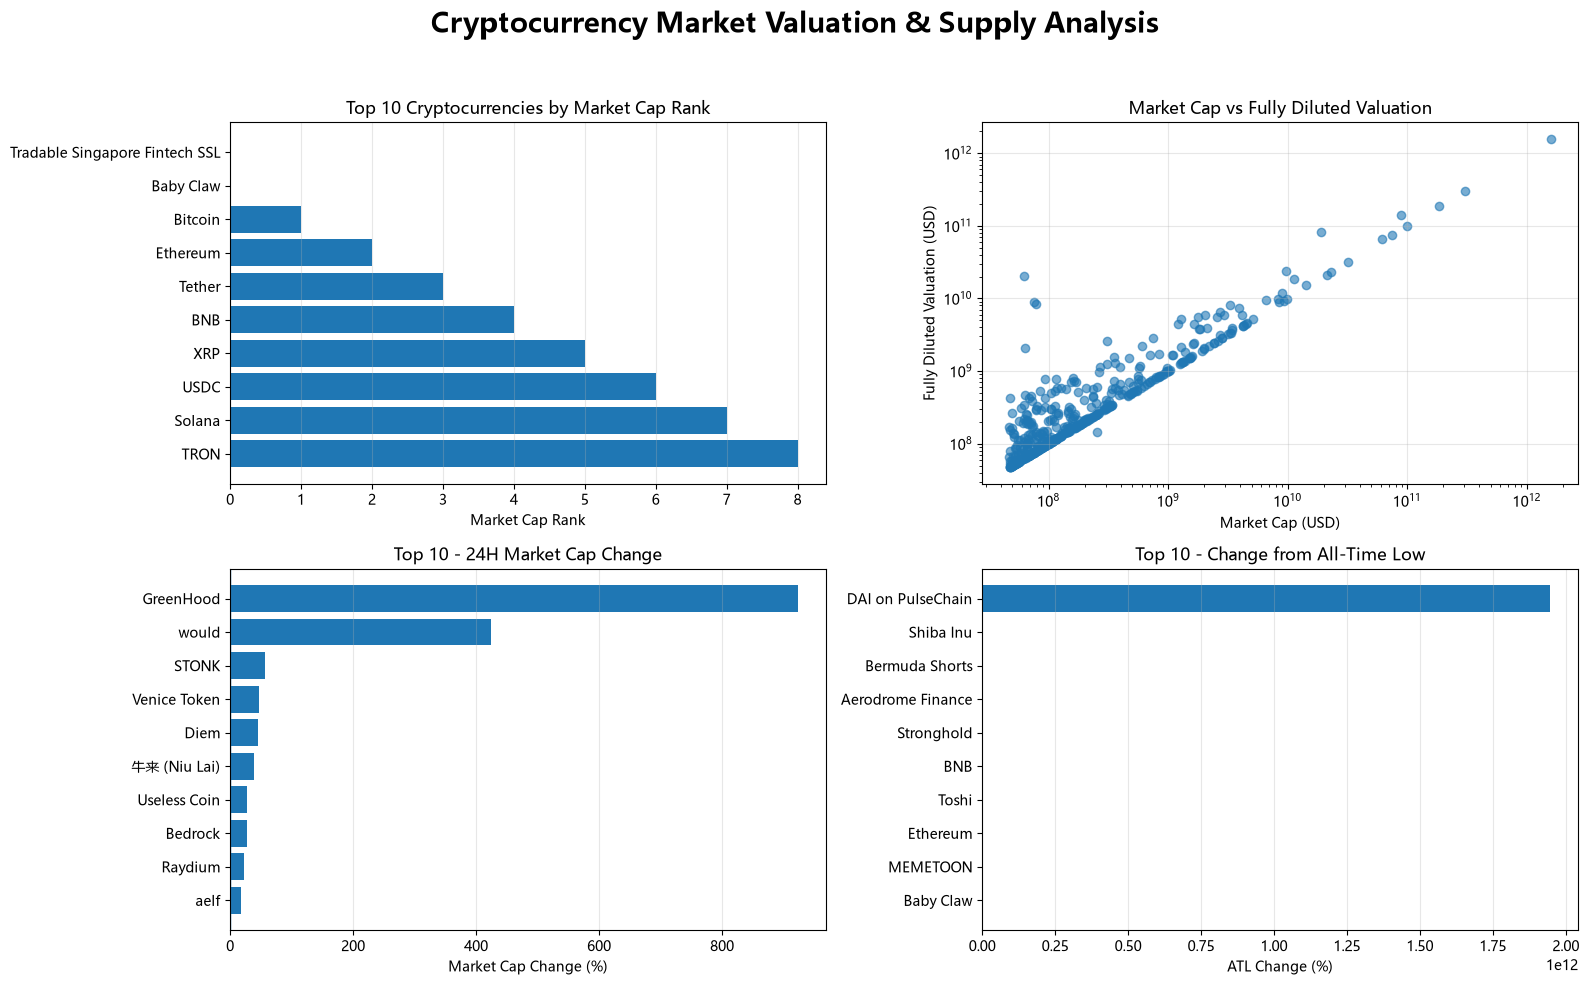

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("cryptocurrency_market_clean_data.csv")

# Convert required columns to numeric
numeric_columns = [
    "Market_Cap_Rank",
    "Fully_Diluted_Valuation",
    "24H_Market_Cap_Change_Percentage",
    "Atl_Change_Percentage"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# -----------------------------------------
# 1. Market Cap Rank
# -----------------------------------------
rank_data = (
    df.sort_values("Market_Cap_Rank")
      .head(10)
      .sort_values("Market_Cap_Rank", ascending=False)
)

axes[0, 0].barh(
    rank_data["Crypto_Name"],
    rank_data["Market_Cap_Rank"]
)

axes[0, 0].set_title("Top 10 Cryptocurrencies by Market Cap Rank")
axes[0, 0].set_xlabel("Market Cap Rank")
axes[0, 0].grid(axis="x", alpha=0.3)


# -----------------------------------------
# 2. Market Cap vs Fully Diluted Valuation
# -----------------------------------------
axes[0, 1].scatter(
    df["Market_Cap"],
    df["Fully_Diluted_Valuation"],
    alpha=0.6
)

axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")

axes[0, 1].set_title("Market Cap vs Fully Diluted Valuation")
axes[0, 1].set_xlabel("Market Cap (USD)")
axes[0, 1].set_ylabel("Fully Diluted Valuation (USD)")
axes[0, 1].grid(alpha=0.3)


# -----------------------------------------
# 3. 24H Market Cap Change %
# -----------------------------------------
change_data = (
    df.dropna(subset=["24H_Market_Cap_Change_Percentage"])
      .assign(
          Absolute_Change=lambda x:
          x["24H_Market_Cap_Change_Percentage"].abs()
      )
      .nlargest(10, "Absolute_Change")
      .sort_values("24H_Market_Cap_Change_Percentage")
)

axes[1, 0].barh(
    change_data["Crypto_Name"],
    change_data["24H_Market_Cap_Change_Percentage"]
)

axes[1, 0].set_title("Top 10 - 24H Market Cap Change")
axes[1, 0].set_xlabel("Market Cap Change (%)")
axes[1, 0].axvline(0, linewidth=1)
axes[1, 0].grid(axis="x", alpha=0.3)


# -----------------------------------------
# 4. Change from All-Time Low
# -----------------------------------------
atl_data = (
    df.dropna(subset=["Atl_Change_Percentage"])
      .nlargest(10, "Atl_Change_Percentage")
      .sort_values("Atl_Change_Percentage")
)

axes[1, 1].barh(
    atl_data["Crypto_Name"],
    atl_data["Atl_Change_Percentage"]
)

axes[1, 1].set_title("Top 10 - Change from All-Time Low")
axes[1, 1].set_xlabel("ATL Change (%)")
axes[1, 1].grid(axis="x", alpha=0.3)


# -----------------------------------------
# Main Title
# -----------------------------------------
fig.suptitle(
    "Cryptocurrency Market Valuation & Supply Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Final Market Analysis

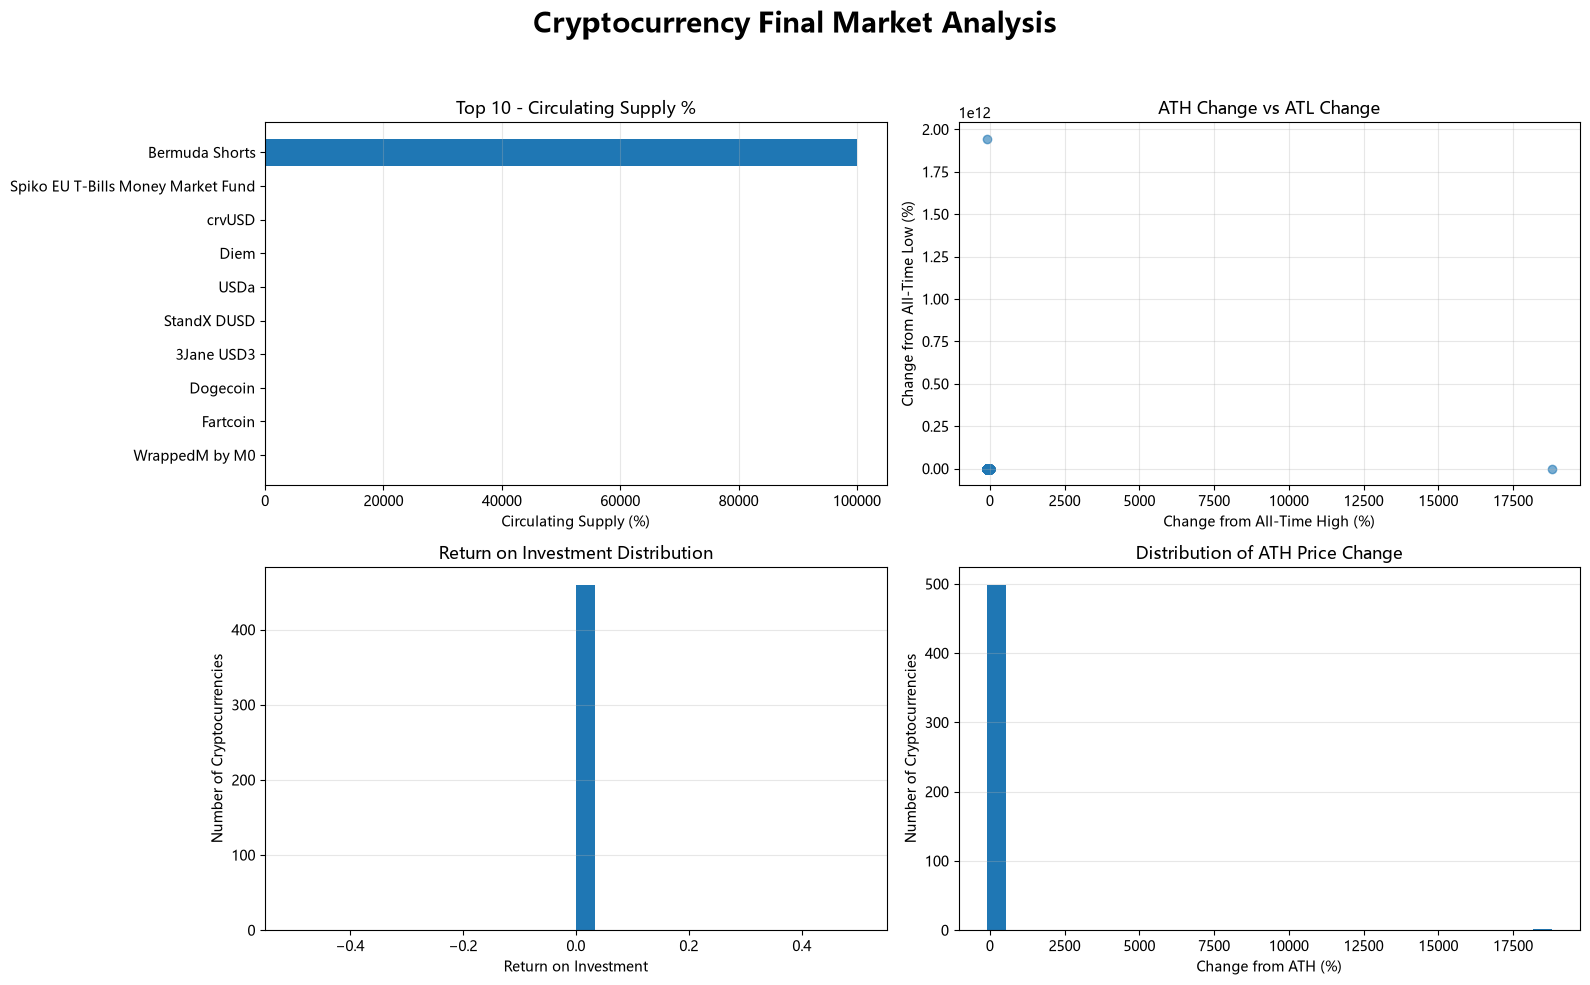

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("cryptocurrency_market_clean_data.csv")

# Convert required columns to numeric
cols = [
    "Circulating_Supply",
    "Total_Supply",
    "Ath_Change_Percentage",
    "Atl_Change_Percentage",
    "Return_On_Investment"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# -----------------------------------------
# 1. Circulating Supply Percentage
# -----------------------------------------
supply = df.dropna(
    subset=["Circulating_Supply", "Total_Supply"]
).copy()

supply = supply[supply["Total_Supply"] > 0]

supply["Circulating_Percentage"] = (
    supply["Circulating_Supply"] /
    supply["Total_Supply"]
) * 100

top_supply = (
    supply.nlargest(10, "Circulating_Percentage")
    .sort_values("Circulating_Percentage")
)

axes[0, 0].barh(
    top_supply["Crypto_Name"],
    top_supply["Circulating_Percentage"]
)

axes[0, 0].set_title("Top 10 - Circulating Supply %")
axes[0, 0].set_xlabel("Circulating Supply (%)")
axes[0, 0].grid(axis="x", alpha=0.3)


# -----------------------------------------
# 2. ATH vs ATL Change
# -----------------------------------------
historical = df.dropna(
    subset=[
        "Ath_Change_Percentage",
        "Atl_Change_Percentage"
    ]
)

axes[0, 1].scatter(
    historical["Ath_Change_Percentage"],
    historical["Atl_Change_Percentage"],
    alpha=0.6
)

axes[0, 1].set_title("ATH Change vs ATL Change")
axes[0, 1].set_xlabel("Change from All-Time High (%)")
axes[0, 1].set_ylabel("Change from All-Time Low (%)")
axes[0, 1].grid(alpha=0.3)


# -----------------------------------------
# 3. ROI Distribution
# -----------------------------------------
roi = df.dropna(
    subset=["Return_On_Investment"]
)

axes[1, 0].hist(
    roi["Return_On_Investment"],
    bins=30
)

axes[1, 0].set_title("Return on Investment Distribution")
axes[1, 0].set_xlabel("Return on Investment")
axes[1, 0].set_ylabel("Number of Cryptocurrencies")
axes[1, 0].grid(axis="y", alpha=0.3)


# -----------------------------------------
# 4. ATH Change Distribution
# -----------------------------------------
ath = df.dropna(
    subset=["Ath_Change_Percentage"]
)

axes[1, 1].hist(
    ath["Ath_Change_Percentage"],
    bins=30
)

axes[1, 1].set_title("Distribution of ATH Price Change")
axes[1, 1].set_xlabel("Change from ATH (%)")
axes[1, 1].set_ylabel("Number of Cryptocurrencies")
axes[1, 1].grid(axis="y", alpha=0.3)


# -----------------------------------------
# Main Title
# -----------------------------------------
fig.suptitle(
    "Cryptocurrency Final Market Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()